In [ ]:
from langgraph.graph import MessagesState
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm1 = HuggingFaceEndpoint(repo_id="Qwen/Qwen2.5-7B-Instruct")
model = ChatHuggingFace(llm=llm1)

In [6]:
class ChatState(MessagesState):
    summary: str

In [9]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [8]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [10]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [14]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

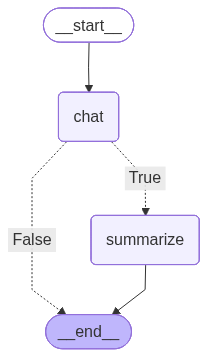

In [15]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [16]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [17]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [18]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d9ab0ad6-7951-4688-84c0-6cfe778911eb')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


In [19]:

run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d9ab0ad6-7951-4688-84c0-6cfe778911eb'), AIMessage(content="Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that studies the physical properties of nature at the scale of atoms and subatomic particles. It is distinct from classical physics in that it deals with phenomena that cannot be described by the principles of classical mechanics.\n\nKey aspects of quantum physics include:\n\n1. **Quantum States and Wavefunctions**: Quantum systems can be described by wavefunctions, which are mathematical functions that determine the probability of different outcomes of measurements. For example, the position and momentum of an electron.\n\n2. **Superposition**: Quantum systems can exist in multiple states at the same time until they are observed or measured. This phenomenon is known as superposition.\n\n3. **Quantum Entanglement**: Entangled particles rem

In [20]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d9ab0ad6-7951-4688-84c0-6cfe778911eb'), AIMessage(content="Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that studies the physical properties of nature at the scale of atoms and subatomic particles. It is distinct from classical physics in that it deals with phenomena that cannot be described by the principles of classical mechanics.\n\nKey aspects of quantum physics include:\n\n1. **Quantum States and Wavefunctions**: Quantum systems can be described by wavefunctions, which are mathematical functions that determine the probability of different outcomes of measurements. For example, the position and momentum of an electron.\n\n2. **Superposition**: Quantum systems can exist in multiple states at the same time until they are observed or measured. This phenomenon is known as superposition.\n\n3. **Quantum Entanglement**: Entangled particles rem

In [21]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d9ab0ad6-7951-4688-84c0-6cfe778911eb'), AIMessage(content="Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that studies the physical properties of nature at the scale of atoms and subatomic particles. It is distinct from classical physics in that it deals with phenomena that cannot be described by the principles of classical mechanics.\n\nKey aspects of quantum physics include:\n\n1. **Quantum States and Wavefunctions**: Quantum systems can be described by wavefunctions, which are mathematical functions that determine the probability of different outcomes of measurements. For example, the position and momentum of an electron.\n\n2. **Superposition**: Quantum systems can exist in multiple states at the same time until they are observed or measured. This phenomenon is known as superposition.\n\n3. **Quantum Entanglement**: Entangled particles rem